In [237]:
from datascience import *
import numpy as np

%matplotlib inline

import matplotlib.pyplot as plt

In [238]:
united = Table.read_table("united.csv")
united = united.with_column("Row", np.arange(united.num_rows)).move_to_start("Row")
united.show(5)

Row,Date,Flight Number,Destination,Delay
0,6/1/15,73,HNL,257
1,6/1/15,217,EWR,28
2,6/1/15,237,STL,-3
3,6/1/15,250,SAN,0
4,6/1/15,267,PHL,64


In [239]:
np.median(united.column("Delay"))
united.num_rows

13825

In [240]:
np.median(united.sample(1000).column("Delay"))

2.0

In [241]:
res = make_array()
def calc_median(n):
    return np.median(united.sample(n).column("Delay"))

In [242]:
for i in range(2000):
    res = np.append(res, calc_median(100))

In [243]:
median_res_100 = Table().with_column("Medians", res)
median_res_100

Medians
2.5
2
5
1
3
3
1
2
4
4.5


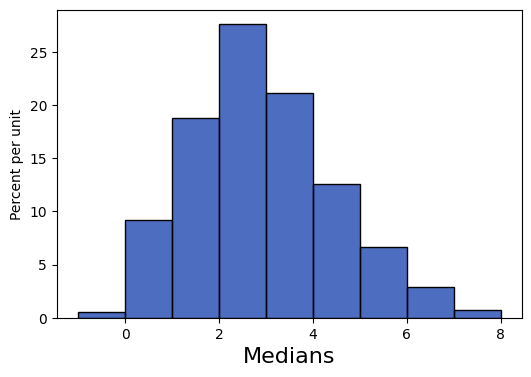

In [244]:
median_res_100.hist(bins=np.arange(-1, 9, 1))

In [245]:
# Swain vs Alabama
pop_props = make_array(0.26, 0.74)
pop_props

array([ 0.26,  0.74])

In [246]:
sample_proportions(100, pop_props)

array([ 0.27,  0.73])

In [247]:
def panel_props():
    return sample_proportions(100, pop_props).item(0)

In [248]:
panels = make_array()

for i in range(10000):
    new_panel = panel_props()*100
    panels = np.append(panels, new_panel)

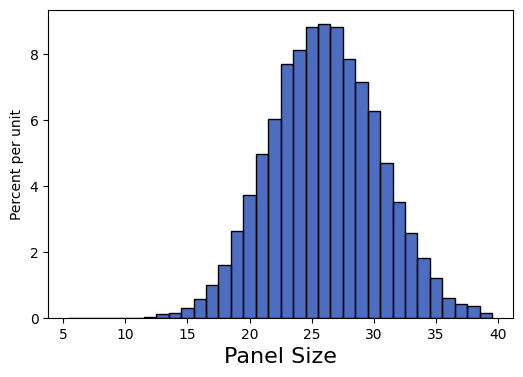

In [249]:
panels_tab = Table().with_column("Panel Size", panels).hist(bins=np.arange(5.5, 40.5, 1))